In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("multiple_linear_regression.csv")

In [4]:
data.head(5)

,Feature 1,Feature 2,Feature 3,Target
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
data.isnull().sum()

Feature 1    0
Feature 2    0
Feature 3    0
Target       0
dtype: int64

## Splitting Data

In [7]:
op_col="Target"

#### iloc is used when there is more than one coloumn to be assigned 

In [9]:
x=data.iloc[:,data.columns!=op_col]

In [10]:
x.head()

,Feature 1,Feature 2,Feature 3
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


#### loc is used when there is one coloumn to be assigned

In [12]:
y=data.loc[:,data.columns==op_col]

In [13]:
y.head()

,Target
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=30)

In [15]:
data.shape

(200, 4)

In [16]:
x_train.shape

(140, 3)

In [17]:
y_test.shape

(60, 1)

### Multiple linear regression

In [19]:
from sklearn.linear_model import LinearRegression 
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [20]:
lr.coef_

array([[0.0444241 , 0.17871113, 0.00512652]])

In [21]:
lr.intercept_

array([3.15340815])

### Prediction

In [23]:
pred_val=lr.predict(x_test)

### Cost

In [25]:
from sklearn.metrics import mean_squared_error
cost=mean_squared_error(y_test,pred_val)
cost


2.54670601452568

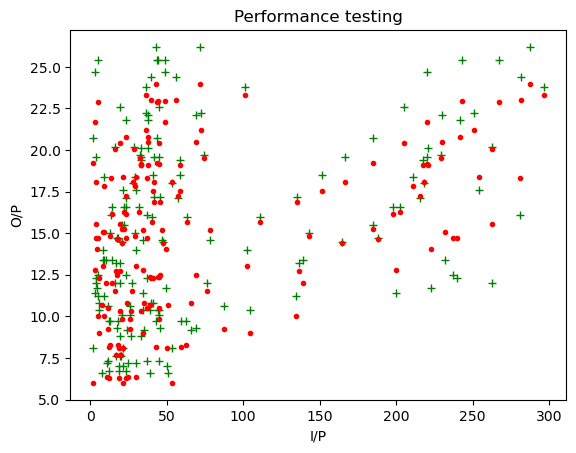

In [26]:
plt.plot(x_test,y_test,"+",color="green")
plt.plot(x_test,pred_val,".",color="red")
plt.title("Performance testing")
plt.xlabel("I/P")
plt.ylabel("O/P")
plt.show()

### Linear Regression Assumptions

In [55]:
len(pred_val)

60

In [57]:
len(y_test)

60

In [51]:
residuals=y_test-pred_val

In [59]:
len(residuals)

60

In [63]:
print(residuals)

       Target
143  1.404825
81  -2.428191
26   0.197558
150 -2.197018
124  0.198504
24   1.433395
126 -4.111181
142  1.023574
129  1.533429
171  0.060768
72  -1.540383
97   0.266859
21  -2.231589
67   1.414713
106  0.817909
184 -0.788587
111  0.999329
63   0.951325
93   1.006982
183  2.217559
86   0.460453
158 -3.199330
133  0.464146
50  -1.360725
99   0.352892
199 -1.645758
189  0.433496
101  0.474809
100 -2.357086
103  0.033708
139  1.478442
57   0.479676
36   2.536620
114 -0.567918
54   0.147989
25  -3.557960
1   -1.984834
149  0.244481
193  1.512329
121 -1.124989
125  1.331242
60   2.102773
90   1.157074
152  0.431624
40   0.303456
17   1.382630
0    1.614571
172 -0.103365
185  2.179300
12  -1.621300
87   0.349176
3    0.935670
147  2.458701
190 -1.482921
59   0.566779
92   0.286178
2   -3.175611
128  2.986713
20  -0.079686
168 -0.135229


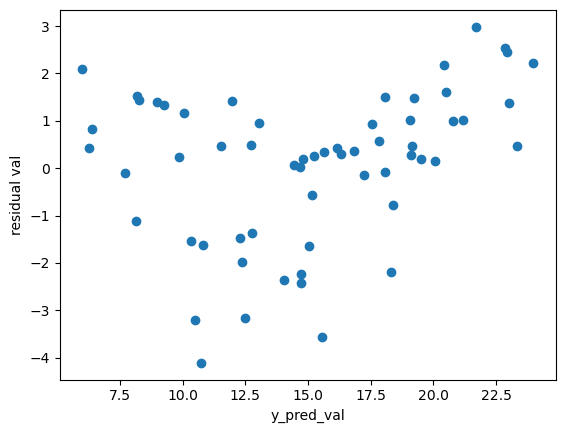

In [71]:
plt.scatter(pred_val,residuals)
plt.xlabel("y_pred_val")
plt.ylabel("residual val")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_24744\2665350104.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals)
C:\Users\Asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

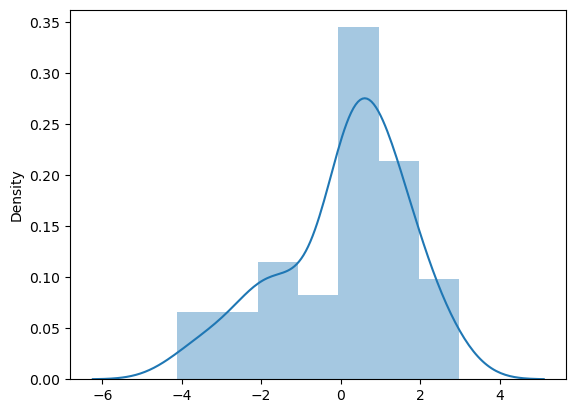

In [78]:
sns.distplot(residuals)

## Ordinary least square model

In [83]:
import statsmodels.api as sm

In [81]:
data.head()

,Feature 1,Feature 2,Feature 3,Target
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [87]:
x_with_const=sm.add_constant(x_train)
x_with_const

,const,Feature 1,Feature 2,Feature 3
5,1.0,8.7,48.9,75.0
8,1.0,8.6,2.1,1.0
180,1.0,156.6,2.6,8.3
94,1.0,107.4,14.0,10.9
42,1.0,293.6,27.7,1.8
...,...,...,...,...
140,1.0,73.4,17.0,12.9
45,1.0,175.1,22.5,31.5
173,1.0,168.4,7.1,12.8
165,1.0,234.5,3.4,84.8


In [89]:
model=sm.OLS(y_train,x_with_const)

In [91]:
result=model.fit()

In [93]:
result.params

const        3.153408
Feature 1    0.044424
Feature 2    0.178711
Feature 3    0.005127
dtype: float64

In [95]:
lr.coef_

array([[0.0444241 , 0.17871113, 0.00512652]])

In [97]:
lr.intercept_

array([3.15340815])

In [99]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     340.0
Date:                Sat, 24 Aug 2024   Prob (F-statistic):           5.54e-63
Time:                        11:47:32   Log-Likelihood:                -274.18
No. Observations:                 140   AIC:                             556.4
Df Residuals:                     136   BIC:                             568.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1534      0.377      8.354      0.0

In [101]:
x_test=sm.add_constant(x_test)

In [103]:
y_pred=result.predict(x_test)

In [105]:
y_pred

143     8.995175
81     14.728191
26     14.802442
150    18.297018
124    19.501496
24      8.266605
126    10.711181
142    19.076426
129     8.166571
171    14.439232
72     10.340383
97     15.233141
21     14.731589
67     11.985287
106     6.382091
184    18.388587
111    20.800671
63     13.048675
93     21.193018
183    23.982441
86     11.539547
158    10.499330
133    19.135854
50     12.760725
99     16.847108
199    15.045758
189     6.266504
101    23.325191
100    14.057086
103    14.666292
139    19.221558
57     12.720324
36     22.863380
114    15.167918
54     20.052011
25     15.557960
1      12.384834
149     9.855519
193    18.087671
121     8.124989
125     9.268758
60      5.997227
90     10.042926
152    16.168376
40     16.296544
17     23.017370
0      20.485429
172     7.703365
185    20.420700
12     10.821300
87     15.650824
3      17.564330
147    22.941299
190    12.282921
59     17.833221
92     19.113822
2      12.475611
128    21.713287
20     18.0796

#### Since according to olr model feature 3 does not play imp role so lets dump feature3 and calculate cost agai

In [116]:
x1=x.iloc[:,x.columns!="Feature 3"]

In [126]:
y1=y

In [138]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.25,random_state=45)

In [140]:
x_train

,Feature 1,Feature 2
183,287.6,43.0
184,253.8,21.3
176,248.4,30.2
167,206.8,5.2
38,43.1,26.7
...,...,...
95,163.3,31.6
32,97.2,1.5
124,229.5,32.3
131,265.2,2.9


In [144]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [150]:
pred_val=lr.predict(x_test)

In [154]:
cost=mean_squared_error(pred_val,y_test)
cost

2.180267924319945

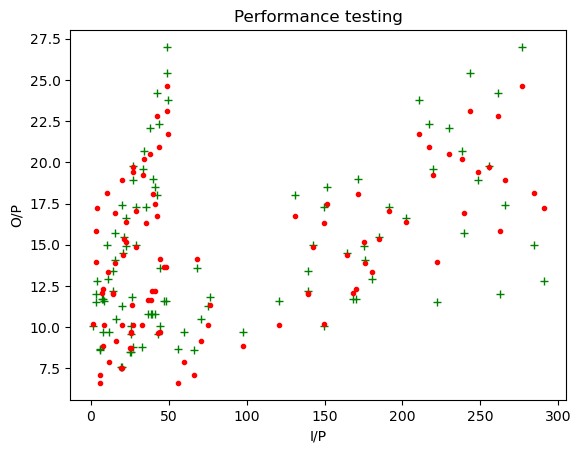

In [156]:
plt.plot(x_test,y_test,"+",color="green")
plt.plot(x_test,pred_val,".",color="red")
plt.title("Performance testing")
plt.xlabel("I/P")
plt.ylabel("O/P")
plt.show()